In [11]:
from manim import *
from electrodynamics_classes import *
import jupyter_capture_output
from numpy import linalg as npl

video_scene = " -v WARNING --disable_caching charged_plane_Scene"
image_scene = f" -v WARNING --disable_caching -r {2*427},{2*240}  -s charged_plane_Scene"

In [95]:
class ChargedPlate(Mobject):
	def __init__(self, plate_center, plate_normal, side_length, z_length, **kwargs):
		super().__init__(**kwargs)

		self.center = plate_center
		self.direction = plate_normal
		self.half_length = side_length / 2

		self.z_length = z_length

		# coordinate system
		self.e_x = UP
		self.e_z = self.direction / npl.norm(self.direction)
		self.e_y = -np.cross(self.e_z, self.e_x)

		x_arrow = Arrow3D(start = self.center, end = self.center + self.e_x, color = RED)
		y_arrow = Arrow3D(start = self.center, end = self.center + self.e_y, color = BLUE)
		z_arrow = Arrow3D(start = self.center, end = self.center + self.e_z, color = WHITE)
		# self.add(x_arrow, y_arrow, z_arrow)


		# plane
		plane_vertices = [
			self.center + self.half_length* (self.e_x+self.e_y),
			self.center + self.half_length* (self.e_x-self.e_y),
			self.center + self.half_length* (-self.e_x-self.e_y),
			self.center + self.half_length* (-self.e_x+self.e_y)
		]

		# plane
		plane = Polygon(*plane_vertices, color = WHITE, fill_color = WHITE, fill_opacity = 0.75, stroke_opacity = 0)
		self.add(plane)

		# horizontal axis
		horizontal_axis = DashedLine(start = self.center + 1.25*self.half_length*self.e_y, end = self.center - 1.25*self.half_length*self.e_y)
		# self.add(horizontal_axis)


		# field point
		field_point_color = WHITE
		self.field_point_coord = self.center+z_length*self.e_z
		field_point_origin = Dot(self.center, radius = 0.03, color = field_point_color)
		field_point = Dot(self.field_point_coord, radius = 0.03, color = field_point_color)
		field_point_line = Line(start = self.center, end = self.field_point_coord, color = field_point_color)
		line_descriptor = MathTex("z", font_size = 24, color = field_point_color).next_to(field_point_line, DOWN)
		# field_point_angle = 
		self.add(field_point_origin, field_point, field_point_line, line_descriptor)

		# radial circle

	def get_ref_point(self, r, phi):
		ref_point_color = RED
		x_ref = r * np.cos(phi) * self.e_x
		y_ref = r * np.sin(phi) * self.e_y
		ref_point_coord = self.center + x_ref + y_ref
		ref_point = Dot(ref_point_coord, radius = 0.03, color = ref_point_color)
		return ref_point

Manim Community v0.18.1

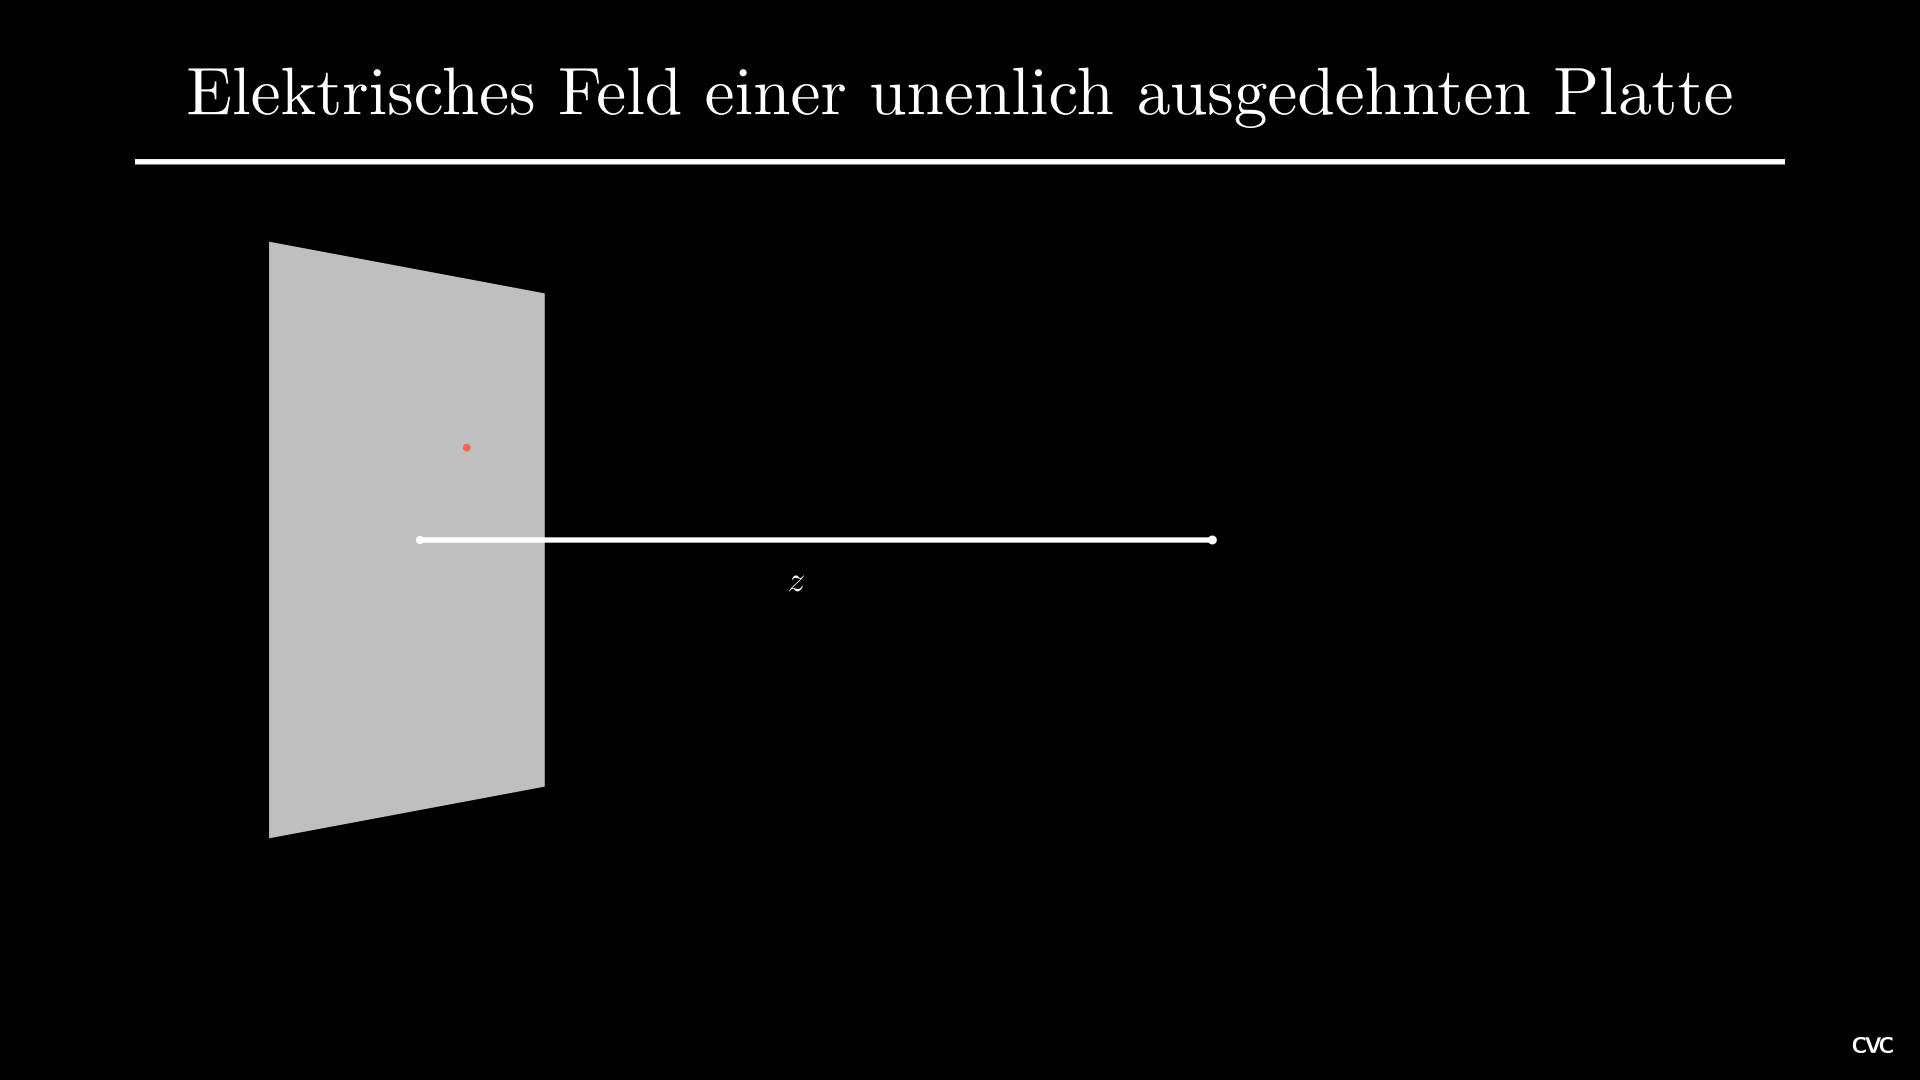

In [96]:
%%manim -qh --fps 60 $video_scene


class charged_plane_Scene(ThreeDScene):
	def construct(self):
		self.camera.background_color = inverted_main_color

		CVC = Text('CVC', font_size = 12, weight = BOLD, color = WHITE, font = 'Latin Modern Sans').align_on_border(RIGHT + DOWN, buff = 0.2)
		self.add(CVC)

		# headline
		headline = Title(r"Elektrisches Feld einer unenlich ausgedehnten Platte", font_size = 48, color = main_color).align_on_border(UP + LEFT, buff = 0.5).shift(0.5 * RIGHT)
		self.add(headline)

		# plate
		plate = ChargedPlate(plate_center = np.array([-4, 0, 0]), plate_normal = np.array([3, 0, 1]), side_length = 4, z_length = 6)
		self.add(plate)

		ref_point = plate.get_ref_point(1, PI/4)
		self.add(ref_point)